# qGAN v4 experiment tutorial

This notebook has two workflows:

1. Execute one generated experiment and visualize its output.
2. Execute a battery of generated experiments.

The `qml_torch` implementation is the working adapter today. `angle_runtime_packed` and `manual_estimator` are scaffolded entry points for future extraction from notebooks and non-QML implementations.

## 1. Setup

Run this notebook from inside the repository or from `qgan_v4/notebooks`. The cell below makes `qgan_v4/src` importable without installing the package.

In [5]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
qgan_v4_dir = None

for candidate in (cwd, *cwd.parents):
    if (candidate / "src" / "qgan_v4").is_dir() and (candidate / "configs").is_dir():
        qgan_v4_dir = candidate
        break
    if (candidate / "qgan_v4" / "src" / "qgan_v4").is_dir():
        qgan_v4_dir = candidate / "qgan_v4"
        break

if qgan_v4_dir is None:
    raise RuntimeError("Could not find qgan_v4 project directory from current working directory.")

repo_root = qgan_v4_dir.parent
src_path = qgan_v4_dir / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("qgan_v4_dir:", qgan_v4_dir)
print("repo_root:", repo_root)

qgan_v4_dir: /home/benat/Qiskit-IBM/qgan_v4
repo_root: /home/benat/Qiskit-IBM


In [6]:
from qgan_v4.config.battery import create_battery_configs
from qgan_v4.config.loader import load_run_config
from qgan_v4.implementations.registry import IMPLEMENTATIONS
from qgan_v4.main import run_battery, run_train
from qgan_v4.storage.paths import get_run_path, get_training_data_filename
from qgan_v4.training.data import load_training_data_file
from qgan_v4.visualization import get_visual_config, run_visualization

sorted(IMPLEMENTATIONS)

['angle_runtime_packed', 'manual_estimator', 'qml_torch']

## 2. Single Experiment

This section expands the test battery, selects one generated config by run id, executes it, then visualizes the checkpoint. The default target is a small angle-encoding smoke test.

In [3]:
battery_path = qgan_v4_dir / "configs" / "batteries" / "test.yaml"
config_files = create_battery_configs(battery_path, overwrite=False)

target_run_id = "ang-qml_torch-q3-noiseless-SPSA-CPU-seed0"
configs_by_run_id = {}

for path in config_files:
    cfg = load_run_config(path)
    configs_by_run_id[cfg["run"]["id"]] = Path(path)

config_path = configs_by_run_id[target_run_id]
config = load_run_config(config_path)
run_path = get_run_path(config)
training_data_file = get_training_data_filename(config)

print("selected config:", config_path)
print("selected run id:", config["run"]["id"])
print("run_path:", run_path)
print("training_data_file:", training_data_file)
print("dataset:", config["dataset"])
print("training:", config["training"])

Creating config files for noiseless_options:
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/base-qml_torch-q3-noiseless-PSR-CPU-seed0/config.yaml
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/base-qml_torch-q3-noiseless-SPSA-CPU-seed0/config.yaml
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/base-qml_torch-q3-noiseless-REG-CPU-seed0/config.yaml
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/ang-qml_torch-q3-noiseless-PSR-CPU-seed0/config.yaml
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/ang-qml_torch-q3-noiseless-SPSA-CPU-seed0/config.yaml
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/ang-qml_torch-q3-noiseless-REG-CPU-seed0/config.yaml
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/amp-qml_torch-q3-noiseless-PSR-CPU-seed0/config.yaml
Confi

### Execute Single Experiment

This runs only the selected config. Increase `training.max_iterations` in the YAML when the smoke test works.

In [4]:
state = run_train(str(config_path))

config = load_run_config(config_path)
training_data_file = get_training_data_filename(config)

              Epoch |     Generator cost | Discriminator cost |               Eval |          Best eval |               Time |
Training complete: 
   Data path: /home/benat/Qiskit-IBM/qgan_v4/data/test/ang-qml_torch-q3-noiseless-SPSA-CPU-seed0 
   Best eval: 0.0 
   Total time: 0.22130346298217773


### Inspect Checkpoint

In [5]:
if training_data_file.exists():
    params = load_training_data_file(training_data_file)
    print("current_epoch:", params.current_epoch)
    print("metric keys:", list(vars(params.metrics).keys()))
    print("eval history:", params.metrics.eval)
else:
    print("No checkpoint yet. Run the single experiment cell first.")


current_epoch: 2
metric keys: ['gloss', 'dloss', 'eval', 'times']
eval history: {0: 0.0, 1: 0.0}


### Visualize Single Experiment

Visualization only reads config files and checkpoints. It does not start training.

Run path: /home/benat/Qiskit-IBM/qgan_v4/data/test/ang-qml_torch-q3-noiseless-SPSA-CPU-seed0
Circuits: 4 (generator, discriminator, randomizer, real circuits)


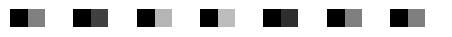

dataset shape: (7, 1, 3) 
data type: float64


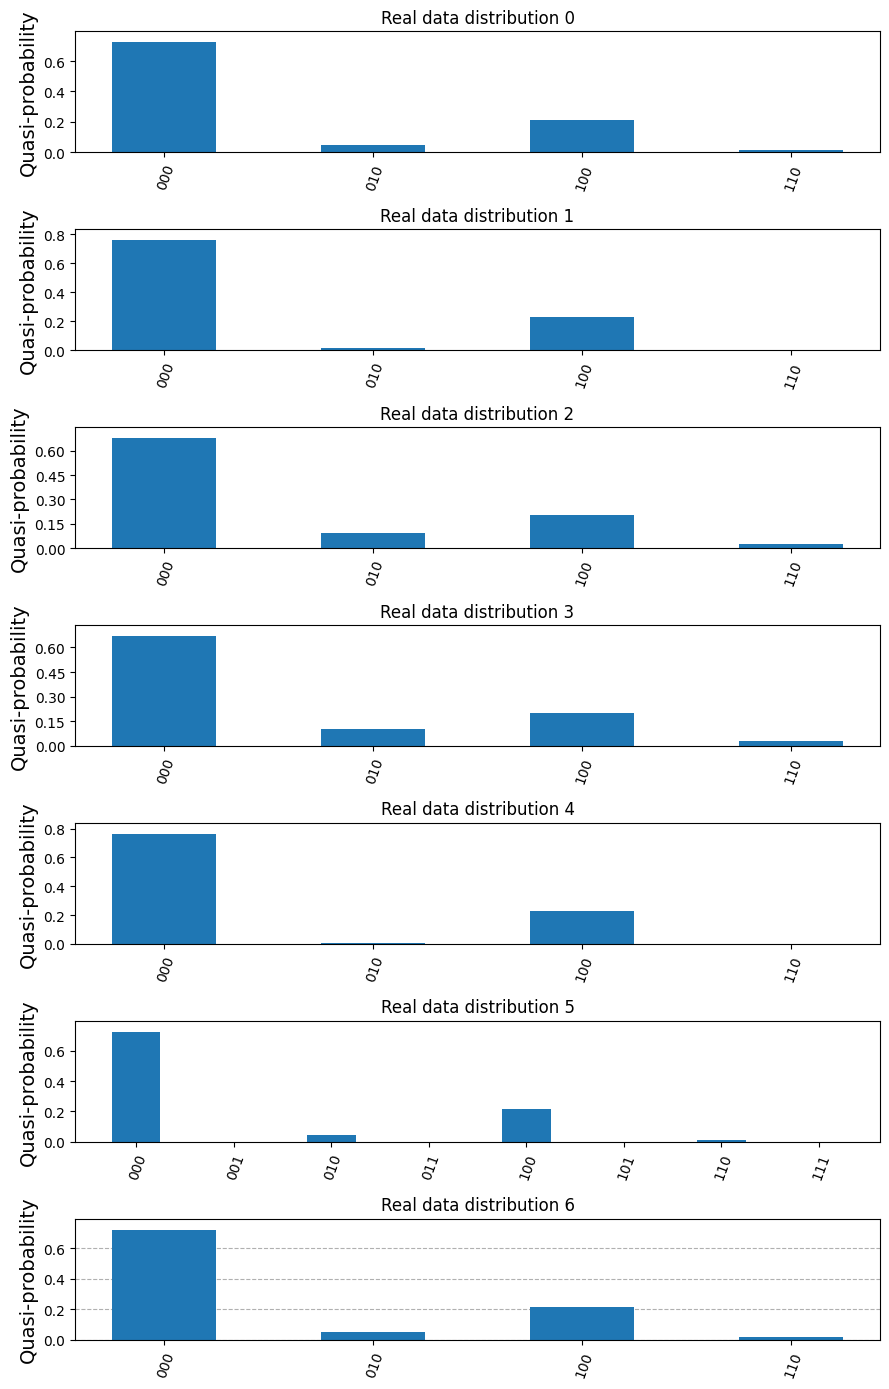

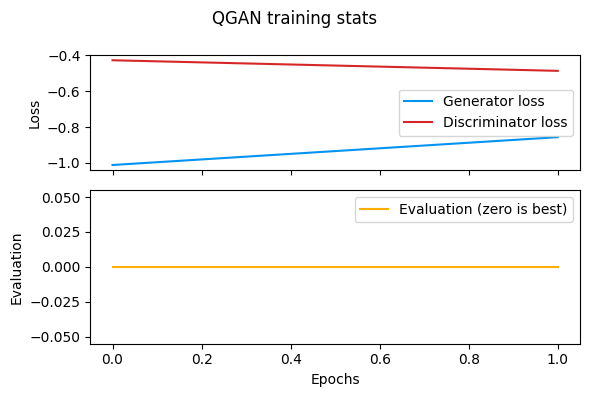

Training complete: /home/benat/Qiskit-IBM/qgan_v4/data/test/ang-qml_torch-q3-noiseless-SPSA-CPU-seed0/training_data.pth 
Best evaluation: 0.0 in epoch 0 
Improvement: 0.0


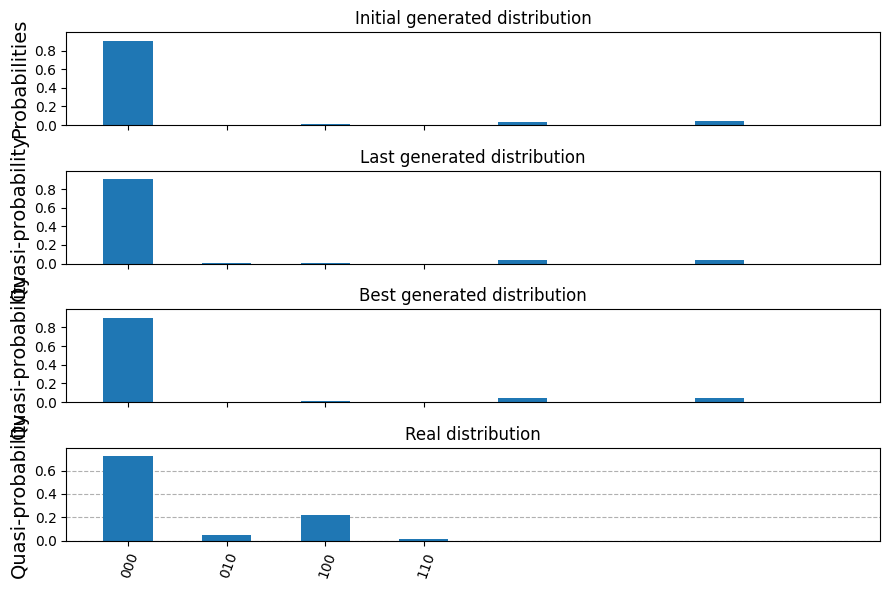

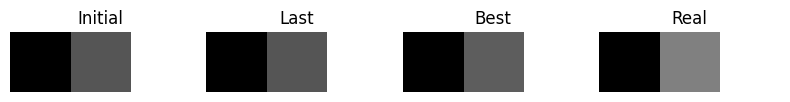

In [6]:
visual_config = get_visual_config({
    "draw_circuits": False,
    "draw_probs": True,
    "draw_images": True,
    "draw_results": True,
})

run = run_visualization(config_path, visual_config)

### Optional Circuit Drawings

Circuit drawings can be large. Enable this only when you want the decomposed real circuits plus generator and discriminator circuit diagrams.

In [7]:
draw_circuits = False

if draw_circuits:
    run = run_visualization(
        config_path,
        {
            "draw_circuits": True,
            "draw_probs": False,
            "draw_images": False,
            "draw_results": False,
        },
    )

## 3. Battery Experiments

This section creates all configs from a battery file and executes the full battery. The default battery is `configs/batteries/test.yaml`, which is intentionally small. Use `configs/batteries/train.yaml` only when you want the larger training sweep.

In [ ]:
battery_path = qgan_v4_dir / "configs" / "batteries" / "test.yaml"
battery_config_files = create_battery_configs(battery_path, overwrite=False)

print("battery:", battery_path)
print("configs:", len(battery_config_files))

for path in battery_config_files:
    cfg = load_run_config(path)
    checkpoint = get_training_data_filename(cfg)
    print(cfg["run"]["id"], "checkpoint_exists=", checkpoint.exists())

Creating config files for noiseless_options:
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/base-qml_torch-q3-noiseless-PSR-CPU-seed0/config.yaml
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/base-qml_torch-q3-noiseless-SPSA-CPU-seed0/config.yaml
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/base-qml_torch-q3-noiseless-REG-CPU-seed0/config.yaml
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/ang-qml_torch-q3-noiseless-PSR-CPU-seed0/config.yaml
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/ang-qml_torch-q3-noiseless-SPSA-CPU-seed0/config.yaml
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/ang-qml_torch-q3-noiseless-REG-CPU-seed0/config.yaml
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/amp-qml_torch-q3-noiseless-PSR-CPU-seed0/config.yaml
Confi

In [7]:
battery_path = qgan_v4_dir / "configs" / "batteries" / "test.yaml"

battery_states = run_battery(battery_path, reset_data=False, reset_rb=False, stop_on_error=False, overwrite=False)
print("completed runs:", len(battery_states))

Creating config files for noiseless_options:
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/base-qml_torch-q3-noiseless-PSR-CPU-seed0/config.yaml
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/base-qml_torch-q3-noiseless-SPSA-CPU-seed0/config.yaml
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/base-qml_torch-q3-noiseless-REG-CPU-seed0/config.yaml
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/ang-qml_torch-q3-noiseless-PSR-CPU-seed0/config.yaml
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/ang-qml_torch-q3-noiseless-SPSA-CPU-seed0/config.yaml
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/ang-qml_torch-q3-noiseless-REG-CPU-seed0/config.yaml
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan_v4/data/test/amp-qml_torch-q3-noiseless-PSR-CPU-seed0/config.yaml
Configuration file rewritten. Path: /hom

/home/benat/Qiskit-IBM/qgan_v4/src/qgan_v4/training/data.py:190: UserWarning: Training data config differs from current config:
- encoding.batch_size: previous=4, current=2
- encoding.eval_batch_size: previous=8, current=2
- encoding.randomness: previous=0, current=0.1
  warn_config_changes(training_state.config, config)


              Epoch |     Generator cost | Discriminator cost |               Eval |          Best eval |               Time |
Training complete: 
   Data path: /home/benat/Qiskit-IBM/qgan_v4/data/test/ang-qml_torch-q3-noiseless-PSR-CPU-seed0 
   Best eval: 0.0 
   Total time: 1.7323687076568604

Running: /home/benat/Qiskit-IBM/qgan_v4/data/test/ang-qml_torch-q3-noiseless-SPSA-CPU-seed0/config.yaml
              Epoch |     Generator cost | Discriminator cost |               Eval |          Best eval |               Time |
Training complete: 
   Data path: /home/benat/Qiskit-IBM/qgan_v4/data/test/ang-qml_torch-q3-noiseless-SPSA-CPU-seed0 
   Best eval: 0.0 
   Total time: 0.22130346298217773

Running: /home/benat/Qiskit-IBM/qgan_v4/data/test/ang-qml_torch-q3-noiseless-REG-CPU-seed0/config.yaml
              Epoch |     Generator cost | Discriminator cost |               Eval |          Best eval |               Time |
Training complete: 
   Data path: /home/benat/Qiskit-IBM/qgan_v4/dat

: 

In [14]:
battery_states

[{'config_file': '/home/benat/Qiskit-IBM/qgan_v4/data/test/base-qml_torch-q3-noiseless-PSR-CPU-seed0/config.yaml',
  'state': None,
  'error': {'type': 'ValueError',
   'message': 'Unknown evaluation method: kl_div',
   'traceback': 'Traceback (most recent call last):\n  File "/home/benat/Qiskit-IBM/qgan_v4/src/qgan_v4/main.py", line 86, in run_battery\n    state = run_train(\n  File "/home/benat/Qiskit-IBM/qgan_v4/src/qgan_v4/main.py", line 40, in run_train\n    return train(config, interrupter=interrupter)\n  File "/home/benat/Qiskit-IBM/qgan_v4/src/qgan_v4/train.py", line 35, in train\n    state = impl.setup(config)\n  File "/home/benat/Qiskit-IBM/qgan_v4/src/qgan_v4/implementations/qml_torch.py", line 66, in setup\n    _, compute_targets = get_evaluation_function(eval_method)\n  File "/home/benat/Qiskit-IBM/qgan_v4/src/qgan_v4/evaluation/torch_metrics.py", line 51, in get_evaluation_function\n    raise ValueError(f"Unknown evaluation method: {eval_method}")\nValueError: Unknown eva

### Inspect Battery Results

In [ ]:
battery_results = []

for path in battery_config_files:
    cfg = load_run_config(path)
    checkpoint = get_training_data_filename(cfg)
    battery_results.append({
        "run_id": cfg["run"]["id"],
        "config": path,
        "checkpoint": checkpoint,
        "checkpoint_exists": checkpoint.exists(),
    })

for result in battery_results:
    print(result["run_id"], "done=" + str(result["checkpoint_exists"]))

## 4. Implementation Adapters

Changing `implementation.name` selects a different adapter. The generic training loop stays the same.

- `qml_torch`: working v4-owned Qiskit Machine Learning + Torch implementation.
- `angle_runtime_packed`: target for extracting the packed Runtime notebook logic.
- `manual_estimator`: target for Qiskit primitives/gradients without `qiskit-machine-learning`.

The scaffolded adapters intentionally raise `NotImplementedError` until their internals are moved from notebooks into source files.

In [ ]:
for path in sorted((qgan_v4_dir / "data" / "test").rglob("config.yaml")):
    cfg = load_run_config(path)
    print(path.relative_to(qgan_v4_dir))
    print("  implementation:", cfg["implementation"]["name"])
    print("  preset:", cfg["experiment"]["implementation"])
    print("  gradient:", cfg["experiment"]["gradient_method"])
    print()